# Feature Selection

Missing-value handling, categorical encoding, correlation pruning, and
RF/permutation importance ranking. All fitting done on train only.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.selection.prepare import prepare_features
from churn.selection.select_features import get_feature_cols, drop_correlated_features, fit_rf_importance

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

train_prepped, test_prepped = prepare_features(train, test)

age median (from train): 42.0
categorical modes (from train): {'gender': 'M', 'marital_status': 'Celibataire'}


categorical dtype categories (from train): {'gender': 3, 'marital_status': 4, 'customer_language': 5}


## Correlation matrix (train only, post-encoding)

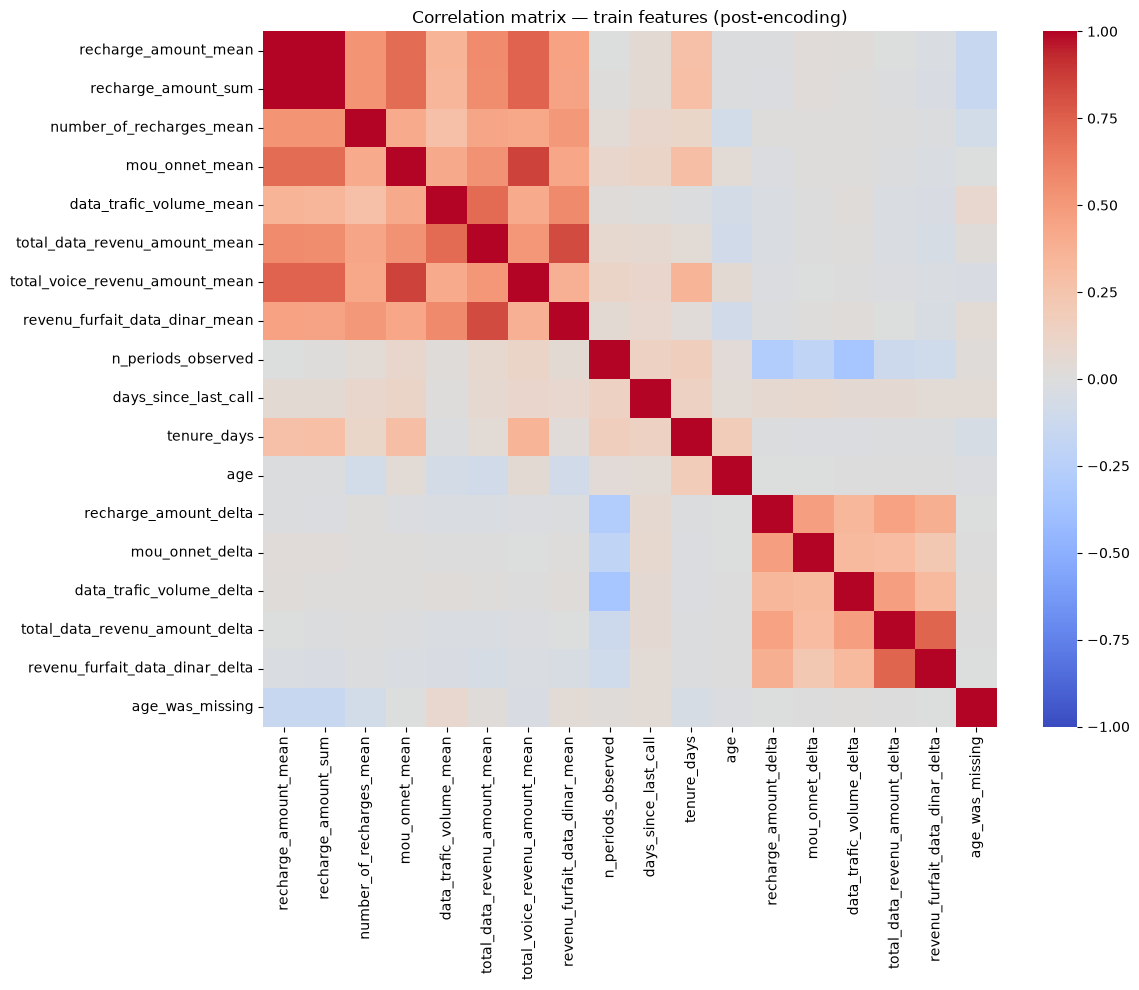

In [2]:
feature_cols = get_feature_cols(train_prepped)
numeric_cols = train_prepped[feature_cols].select_dtypes(include="number").columns
corr = train_prepped[numeric_cols].corr()

fig = plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — train features (post-encoding)")
plt.tight_layout()
save_fig(fig, "06_selection_correlation_heatmap")
plt.show()

In [3]:
kept_features = drop_correlated_features(train_prepped)

  skipping correlation pruning for categorical columns: ['gender', 'marital_status', 'customer_language']


  dropping 'recharge_amount_sum' (correlated 1.00 with 'recharge_amount_mean')
  dropping 'total_voice_revenu_amount_mean' (correlated 0.86 with 'mou_onnet_mean')
  dropping 'revenu_furfait_data_dinar_mean' (correlated 0.82 with 'total_data_revenu_amount_mean')
Correlation pruning: dropped 3, kept 18 features


## Feature importance (RF + permutation, fit on train only)

                        feature  rf_importance  permutation_importance
                    tenure_days       0.185172            8.702928e-02
        data_trafic_volume_mean       0.112865            5.871466e-02
                            age       0.076003            5.836588e-02
                 mou_onnet_mean       0.142420            3.979901e-02
           recharge_amount_mean       0.094281            3.339958e-02
                       gender_M       0.004634            3.053229e-02
           days_since_last_call       0.056860            2.953463e-02
       number_of_recharges_mean       0.072714            2.823469e-02
  total_data_revenu_amount_mean       0.037092            2.600393e-02
        customer_language_Arabe       0.005548            1.899558e-02
       data_trafic_volume_delta       0.038002            1.872527e-02
      customer_language_Missing       0.015088            1.838230e-02
     customer_language_Français       0.003304            1.578532e-02
      

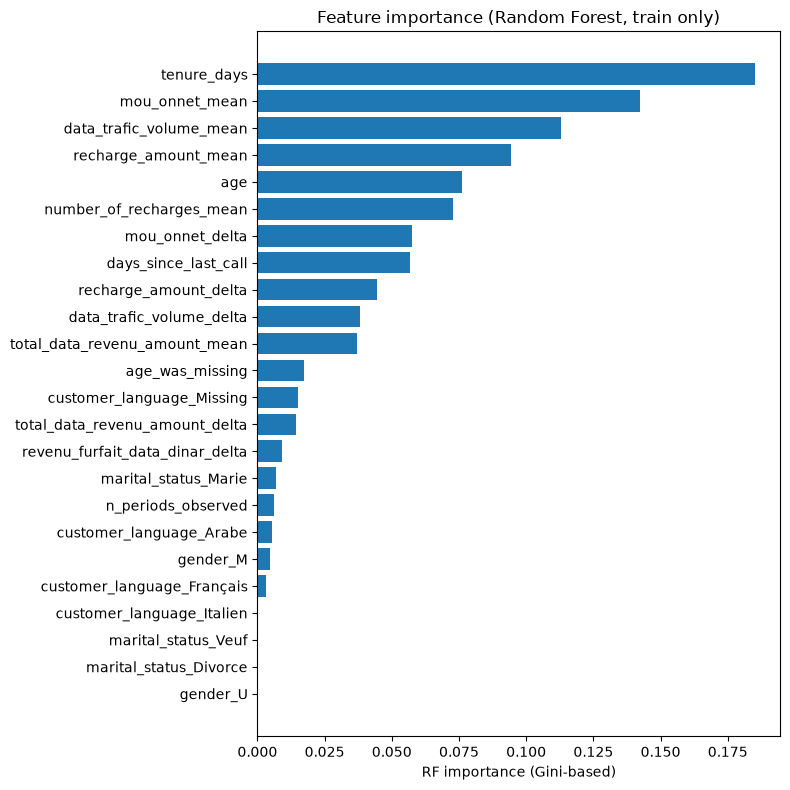

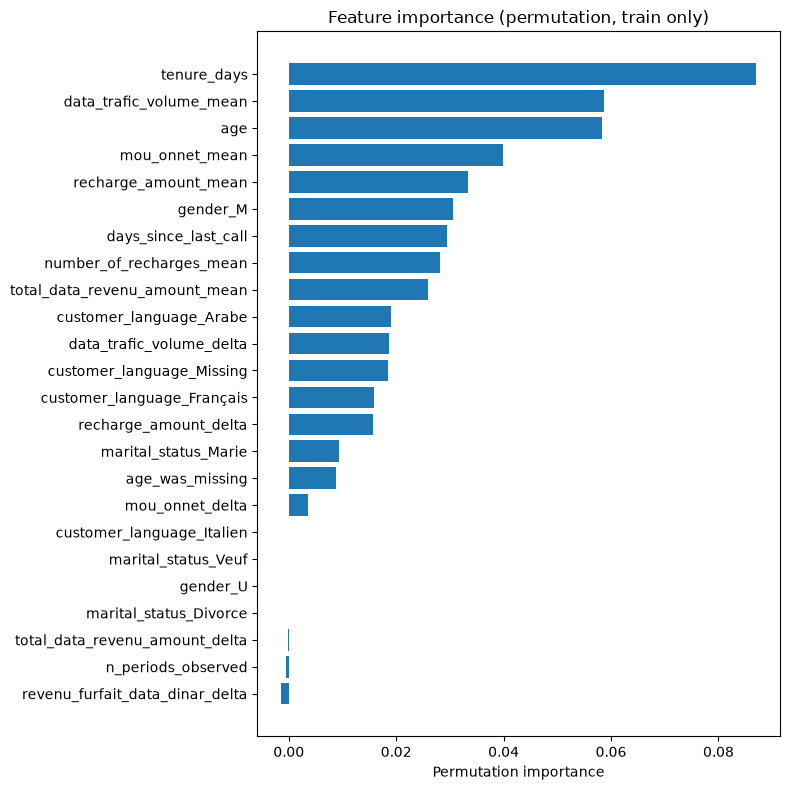

In [4]:
importance_df = fit_rf_importance(train_prepped, kept_features)
print(importance_df.to_string(index=False))

# RF importance (Gini-based, built-in) -- same importance_df computed above,
# no new fitting. Sorted by its own metric here, same as the permutation
# chart below is sorted by its own metric.
rf_sorted = importance_df.sort_values("rf_importance", ascending=False)
fig = plt.figure(figsize=(8, 8))
plt.barh(rf_sorted["feature"], rf_sorted["rf_importance"])
plt.xlabel("RF importance (Gini-based)")
plt.title("Feature importance (Random Forest, train only)")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "07a_selection_rf_importance")
plt.show()

fig = plt.figure(figsize=(8, 8))
plt.barh(importance_df["feature"], importance_df["permutation_importance"])
plt.xlabel("Permutation importance")
plt.title("Feature importance (permutation, train only)")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "07_selection_feature_importance")
plt.show()

**Observations — RF vs. permutation importance**

- **The two RF-based lenses agree closely, unlike the Logistic Regression comparison below.** Spearman rank correlation between RF (Gini-based) and permutation importance is **0.711** (p < 0.001) across all 24 features — a strong, statistically significant monotonic relationship. **The top 5 are now the same set** for both metrics (`tenure_days`, `data_trafic_volume_mean`, `age`, `mou_onnet_mean`, `recharge_amount_mean`), just in a different order.
- **Where they diverge, it's mostly about scale/cardinality bias, not disagreement on signal.** RF's built-in (Gini) importance is known to favor continuous/high-cardinality features, which permutation importance corrects for — this shows up most clearly for `gender_M` (permutation rank 6 vs. RF rank 19: a low-cardinality binary flag that RF's split-count-based metric underweights relative to its real predictive value) and `mou_onnet_delta` (RF rank 7 vs. permutation rank 17, the reverse pattern).
- **`n_periods_observed` and the two delta features already flagged as negative-permutation-importance** (`revenu_furfait_data_dinar_delta`, `total_data_revenu_amount_delta`) are a useful check here: none of the three ranks highly on RF importance either (ranks 17, 15, 14 of 24) — RF's own signal is weak for these three too, it just doesn't go negative the way permutation importance does. This is consistent with the earlier finding that only `n_periods_observed` was dropped: it's genuinely the weakest of the three by both metrics.
- **Bottom line:** RF and permutation importance mostly reinforce each other here, which is expected since permutation importance is computed on the same fitted RF model — the Logistic Regression comparison below is the one that shows genuine divergence, because it's a structurally different (linear) model.

## Feature importance (Logistic Regression, train only) — comparative exhibit

A third, independent importance lens alongside RF + permutation importance
above — same `kept_features`, same train-only fitting discipline. This is
purely comparative: it does **not** change which features get dropped or
kept (that decision is already finalized by the correlation pruning +
RF/permutation logic above). LogisticRegression coefficients are
scale-sensitive (unlike RF's split-based importance), so this fits on a
`StandardScaler`-transformed copy of the training features — a local scaler
for this diagnostic only, separate from and not affecting the actual
step-8 modeling pipeline's own scaling.

                        feature  abs_coefficient
                 mou_onnet_mean         1.838941
           recharge_amount_mean         1.683447
          recharge_amount_delta         1.121972
             n_periods_observed         0.867302
  total_data_revenu_amount_mean         0.792571
                mou_onnet_delta         0.787647
                age_was_missing         0.612623
 total_data_revenu_amount_delta         0.555713
        customer_language_Arabe         0.539586
           marital_status_Marie         0.518407
        data_trafic_volume_mean         0.438676
      customer_language_Missing         0.416536
revenu_furfait_data_dinar_delta         0.382479
       number_of_recharges_mean         0.174492
                    tenure_days         0.141831
                       gender_M         0.123131
           days_since_last_call         0.116198
                            age         0.058570
         marital_status_Divorce         0.050355
      customer_langu

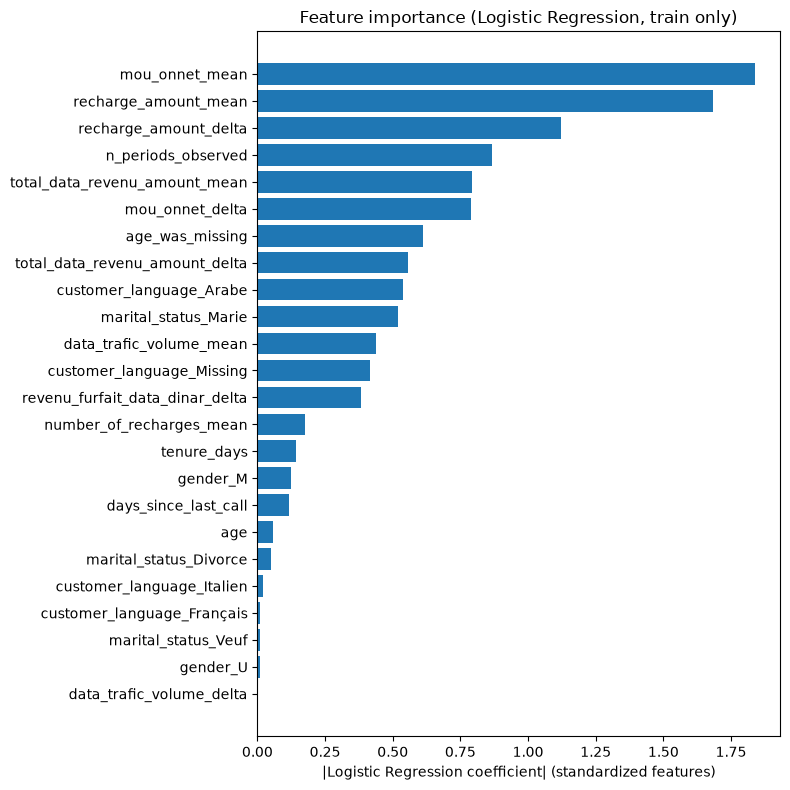

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_lr = train_prepped[kept_features]
y_lr = train_prepped["label"]

# Same local one-hot-encoding-for-categoricals approach as fit_rf_importance
# above -- LogisticRegression has no native categorical support either.
categorical_cols = list(X_lr.select_dtypes(include="category").columns)
if categorical_cols:
    X_lr = pd.get_dummies(X_lr, columns=categorical_cols, drop_first=True)

X_lr_scaled = StandardScaler().fit_transform(X_lr)

lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr.fit(X_lr_scaled, y_lr)

lr_importance_df = pd.DataFrame({
    "feature": X_lr.columns,
    "abs_coefficient": abs(lr.coef_[0]),
}).sort_values("abs_coefficient", ascending=False)

print(lr_importance_df.to_string(index=False))

fig = plt.figure(figsize=(8, 8))
plt.barh(lr_importance_df["feature"], lr_importance_df["abs_coefficient"])
plt.xlabel("|Logistic Regression coefficient| (standardized features)")
plt.title("Feature importance (Logistic Regression, train only)")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "07b_selection_lr_importance")
plt.show()

**Observations — Logistic Regression importance (comparative)**

- **The two rankings diverge substantially, not just at the margins.** Spearman rank correlation between the RF/permutation ranking and the Logistic Regression ranking is **0.105** (p = 0.62, not statistically significant) across all 24 features — essentially no monotonic agreement. **2 of the top 5** overlap between the two lenses (`mou_onnet_mean`, `recharge_amount_mean`).
- **RF/permutation's top 5** (`tenure_days`, `data_trafic_volume_mean`, `age`, `mou_onnet_mean`, `recharge_amount_mean`) are mostly tenure/usage-volume features. **Logistic Regression's top 5** (`mou_onnet_mean`, `recharge_amount_mean`, `recharge_amount_delta`, `n_periods_observed`, `total_data_revenu_amount_mean`) are mostly raw usage/spend levels and their month-over-month deltas.
- **The most notable single divergence: `n_periods_observed`.** RF/permutation importance ranks it near the bottom (slightly negative — the reason it was dropped from the final feature set, see below), but Logistic Regression ranks it **4th highest**. A plausible explanation: `n_periods_observed` is redundant with `tenure_days`/`days_since_last_call` (already noted below), and under collinearity, a linear model's coefficients can redistribute "credit" unevenly across correlated predictors, inflating one while a permutation-importance test (which measures the marginal cost of losing just that one feature, with its correlated proxies still present) shows near-zero for the same feature. `age` shows a related but opposite pattern: RF ranks it 5th and permutation ranks it 3rd, but Logistic Regression ranks it 18th of 24 (0.059) — age likely has a more non-linear or interaction-driven relationship with churn (consistent with the EDA, where churn peaked mid-range and plateaued rather than moving monotonically with age) that a linear model can't represent as a single coefficient the way RF's splits can.
- **This divergence doesn't change the feature selection decision.** As stated above, this is a comparative exhibit only — the correlation-pruning + RF/permutation-based selection and its resulting feature set (below) remain exactly as they were.

**Observations — Feature selection**

- **Correlation pruning removed 3 redundant features:** `recharge_amount_sum` (perfectly correlated with `recharge_amount_mean`), `total_voice_revenu_amount_mean` (correlated with `mou_onnet_mean`), and `revenu_furfait_data_dinar_mean` (0.82 correlated with `total_data_revenu_amount_mean` — both effectively "how much they spend on data").

- **`classe_anciennete` is excluded from the modeling feature set entirely**, ahead of this step. It was verified to be a near-perfect bucketing of `tenure_days` (zero overlap between adjacent buckets at cutoffs of 73/256/986 days; only 95 rank inversions out of 393,205 rows — noise-level), so it was splitting the same tenure signal across a continuous feature and a redundant categorical, the same way `revenu_furfait_data_dinar_mean` split spend signal above. `tenure_days` is kept instead since it's continuous and lets tree models find their own split points; `classe_anciennete` remains available in `subscriber_static.parquet` for EDA/reporting.

- **`recency_tenure_ratio` (inactivity relative to tenure) is also excluded from the modeling feature set entirely**, for the same class of reason. It's mechanically derived from `tenure_days` (`days_since_last_call / tenure_days`, Spearman -0.97 between the two raw features), and a SHAP diagnostic found it was splitting `tenure_days`'s true importance between the two nearly-redundant columns rather than adding independent signal — removing it recovered a large share of `tenure_days`'s importance with no meaningful cost to model performance (recall/precision/F1/ROC-AUC/PR-AUC all moved by <0.5pt for both XGBoost and LightGBM). `tenure_days` now ranks **#1 by both RF and permutation importance** (previously 3rd, with credit split against `recency_tenure_ratio`).

- **`tenure_days` now ranks highest by both metrics**, followed by `mou_onnet_mean`/`data_trafic_volume_mean`, `age`, and `recharge_amount_mean` — the same five features top both the RF and permutation rankings (just reordered between them). This is consistent with the EDA and survival analysis, where tenure was the single strongest churn indicator.

- **Mixed missing-value treatment for demographics**, unchanged: `gender`/`marital_status` are mode-imputed (train-only, native category dtype), `customer_language` keeps `Missing` as its own category (its mode, `Anglais`, is also the highest-churn language group, so imputing with it would distort that signal). `age_was_missing` contributes very little on its own.

- **Very small categories contribute almost nothing** (`gender_U`, `marital_status_Divorce`, `marital_status_Veuf`, `customer_language_Italien`) in the one-hot view used only for this RandomForest importance ranking — the actual exported feature set keeps these as native categorical columns, not one-hot dummies.

- **`n_periods_observed` dropped** (slightly negative permutation importance, and the smallest RF importance of the three features with negative permutation importance in this run), redundant with `tenure_days`/`days_since_last_call`. `revenu_furfait_data_dinar_delta` and `total_data_revenu_amount_delta` also show slightly negative permutation importance here but are kept in the final feature set — their permutation importance is close to zero (noise-level) rather than clearly negative, and their RF importance remains non-trivial.

**Decision:** Final feature set: 17 features (20 columns total including subscriber_id, snapshot_date, label).